# Streaming


In [1]:
import os 
from dotenv import load_dotenv
from langchain_deepseek import ChatDeepSeek

load_dotenv("apikey.env")
os.environ['LANGCHAIN_TRACING_V2'] = 'true'
os.environ['LANGCHAIN_ENDPOINT'] = 'https://api.smith.langchain.com'
os.environ['LANGCHAIN_API_KEY'] = os.getenv("LANGCHAIN_API_KEY")
os.environ['LANGCHAIN_PROJECT'] = "graph streaming"
BASE_URL = 'https://api.deepseek.com'
API_KEY = os.getenv('DEEPSEEK-API-KEY')


In [2]:
model = ChatDeepSeek(api_key=API_KEY, model="deepseek-chat", temperature=0.7)

In [3]:
from langchain_core.messages import SystemMessage, RemoveMessage, HumanMessage
from langchain_core.runnables import RunnableConfig

from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import StateGraph, START, END
from langgraph.graph import MessagesState

class State(MessagesState):
    summary: str

# Define the logic to call the model
def call_model(state: State, config: RunnableConfig):
    # Get summary if it exists
    summary = state.get("summary", "")
    # If there is summary, then we add it
    if summary:
        # Add summary to system message
        system_message = f"Summary of conversation earlier: {summary}"
        # Append summary to any newer messages
        messages = [SystemMessage(content=system_message)] + state["messages"]
    else:
        messages = state["messages"]
    
    response = model.invoke(messages, config)
    return {"messages": response}

def summarize_conversation(state: State):
    # First, we get any existing summary
    summary = state.get("summary", "")
    # Create our summarization prompt 
    if summary:
        # A summary already exists
        summary_message = (
            f"This is summary of the conversation to date: {summary}\n\n"
            "Extend the summary by taking into account the new messages above:"
        )
    else:
        summary_message = "Create a summary of the conversation above:"
    # Add prompt to our history
    messages = state["messages"] + [HumanMessage(content=summary_message)]
    response = model.invoke(messages)
    # Delete all but the 2 most recent messages
    delete_messages = [RemoveMessage(id=m.id) for m in state["messages"][:-2]]
    return {"summary": response.content, "messages": delete_messages}

# Determine whether to end or summarize the conversation
def should_continue(state: State):
    """Return the next node to execute."""
    messages = state["messages"]
    # If there are more than six messages, then we summarize the conversation
    if len(messages) > 6:
        return "summarize_conversation"
    # Otherwise we can just end
    return END


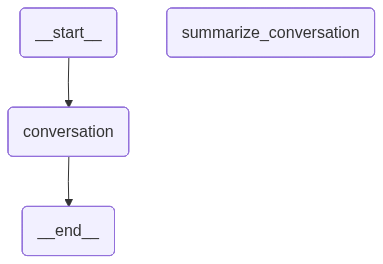

In [4]:
from IPython.display import Image, display

# Define a new graph
workflow = StateGraph(State)
workflow.add_node("conversation", call_model)
workflow.add_node(summarize_conversation)

# Set the entrypoint as conversation
workflow.add_edge(START, "conversation")
workflow.add_conditional_edges("conversation", should_continue)
workflow.add_edge("summarize_conversation", END)

# Compile
memory = MemorySaver()
graph = workflow.compile(checkpointer=memory)
display(Image(graph.get_graph().draw_mermaid_png()))

Streaming full state

Now, let's talk about ways to stream our graph state.

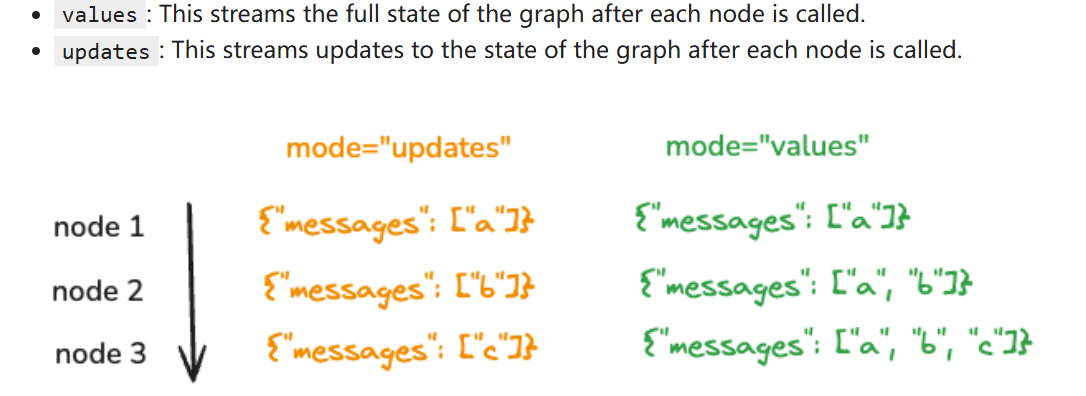

$\large{mode="update"}$

In [5]:
# Create a thread
config = {"configurable": {"thread_id": "1"}}

# Start conversation
messages = {"messages": [HumanMessage(content="你好我是怀民！\(@^0^@)/")]}
for chunk in graph.stream(messages, config, stream_mode="updates"):
    print(chunk)

{'conversation': {'messages': AIMessage(content='怀民你好呀！看到你的颜文字表情都感觉屏幕变可爱了呢！(≧▽≦) 今天是想聊什么有趣的话题，还是需要帮忙解决什么问题呢？我随时准备好当你的小助手啦～', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 49, 'prompt_tokens': 16, 'total_tokens': 65, 'completion_tokens_details': None, 'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 0}, 'prompt_cache_hit_tokens': 0, 'prompt_cache_miss_tokens': 16}, 'model_name': 'deepseek-chat', 'system_fingerprint': 'fp_ffc7281d48_prod0820_fp8_kvcache', 'id': '598e0c01-67a8-40ef-9b1d-89b8a7011621', 'service_tier': None, 'finish_reason': 'stop', 'logprobs': None}, id='run--36753130-1885-4c46-a918-fc0945e6a14b-0', usage_metadata={'input_tokens': 16, 'output_tokens': 49, 'total_tokens': 65, 'input_token_details': {'cache_read': 0}, 'output_token_details': {}})}}


In [6]:
for chunk in graph.stream(messages, config, mode="update"):
    chunk["conversation"]["messages"].pretty_print()

================================== Ai Message ==================================

哈哈，怀民带着这么可爱的颜文字突然出现，是不是有什么脑洞想分享呀？(๑•̀ㅂ•́)و✧ 无论是想聊苏轼笔下那个“夜游承天寺”的经典怀民，还是单纯想给今天找点乐子，我都准备好接招啦～快来发射你的奇思妙想！


$\large{mode="values"}$

In [7]:
# Start conversation, again
config = {"configurable": {"thread_id": "2"}}

# Start conversation
input_messages = {"messages": [HumanMessage(content="嘿嘿嘿，我是熊大！")]}
for event in graph.stream(input_messages, config, stream_mode="values"):
    for m in event['messages']:
        m.pretty_print()
    print("---"*25)

================================ Human Message =================================

嘿嘿嘿，我是熊大！
---------------------------------------------------------------------------
================================ Human Message =================================

嘿嘿嘿，我是熊大！
================================== Ai Message ==================================

（跺脚拍肚皮）嘿！光头强又在偷偷砍树是吧？俺老远就听见电锯声啦！快跟俺去瞧瞧！（拽着你往森林跑）今天非得用蜂蜜陷阱把他困住不可，你可要帮俺多捡点松果当弹药！🐻
---------------------------------------------------------------------------


## Streaming tokens



We can do this using the `.astream_events` method, which streams back events as they happen inside nodes!

关键在于，图中聊天模型生成的令牌具有 `on_chat_model_stream` 类型。

In [8]:
config = {"configurable": {"thread_id": "3"}}
input_message = HumanMessage(content="请你介绍 49ers NFL team")
async for event in graph.astream_events({"messages": [input_message]}, config, version="v2"):
    print(f"Node: {event['metadata'].get('langgraph_node','')}. Type: {event['event']}. Name: {event['name']}")

Node: . Type: on_chain_start. Name: LangGraph
Node: conversation. Type: on_chain_start. Name: conversation
Node: conversation. Type: on_chat_model_start. Name: ChatDeepSeek
Node: conversation. Type: on_chat_model_stream. Name: ChatDeepSeek
Node: conversation. Type: on_chat_model_stream. Name: ChatDeepSeek
Node: conversation. Type: on_chat_model_stream. Name: ChatDeepSeek
Node: conversation. Type: on_chat_model_stream. Name: ChatDeepSeek
Node: conversation. Type: on_chat_model_stream. Name: ChatDeepSeek
Node: conversation. Type: on_chat_model_stream. Name: ChatDeepSeek
Node: conversation. Type: on_chat_model_stream. Name: ChatDeepSeek
Node: conversation. Type: on_chat_model_stream. Name: ChatDeepSeek
Node: conversation. Type: on_chat_model_stream. Name: ChatDeepSeek
Node: conversation. Type: on_chat_model_stream. Name: ChatDeepSeek
Node: conversation. Type: on_chat_model_stream. Name: ChatDeepSeek
Node: conversation. Type: on_chat_model_stream. Name: ChatDeepSeek
Node: conversation. Typ

We can use `event['metadata']['langgraph_node']` to select the node to stream from.

And we can use `event['data']` to get the actual data for each event, which in this case is an AIMessageChunk.

In [12]:
node_to_stream = 'conversation'
config = {"configurable": {"thread_id": "4"}}
input_message = HumanMessage(content="你好")
async for event in graph.astream_events({"messages": [input_message]}, config, version="v2"):
    # Get chat model tokens from a particular node 
    if event["event"] == "on_chat_model_stream" and event['metadata'].get('langgraph_node','') == node_to_stream:
        print(event["data"])

{'chunk': AIMessageChunk(content='', additional_kwargs={}, response_metadata={}, id='run--1cd7dcad-c1dd-4649-8e36-43da17b27337')}
{'chunk': AIMessageChunk(content='你好', additional_kwargs={}, response_metadata={}, id='run--1cd7dcad-c1dd-4649-8e36-43da17b27337')}
{'chunk': AIMessageChunk(content='！', additional_kwargs={}, response_metadata={}, id='run--1cd7dcad-c1dd-4649-8e36-43da17b27337')}
{'chunk': AIMessageChunk(content='三', additional_kwargs={}, response_metadata={}, id='run--1cd7dcad-c1dd-4649-8e36-43da17b27337')}
{'chunk': AIMessageChunk(content='度', additional_kwargs={}, response_metadata={}, id='run--1cd7dcad-c1dd-4649-8e36-43da17b27337')}
{'chunk': AIMessageChunk(content='相遇', additional_kwargs={}, response_metadata={}, id='run--1cd7dcad-c1dd-4649-8e36-43da17b27337')}
{'chunk': AIMessageChunk(content='，', additional_kwargs={}, response_metadata={}, id='run--1cd7dcad-c1dd-4649-8e36-43da17b27337')}
{'chunk': AIMessageChunk(content='看来', additional_kwargs={}, response_metadata={},

In [14]:
node_to_stream = 'conversation'
config = {"configurable": {"thread_id": "4"}}
input_message = HumanMessage(content="请你介绍langgraph")
async for event in graph.astream_events({"messages": [input_message]}, config, version="v2"):
    # Get chat model tokens from a particular node 
    if event["event"] == "on_chat_model_stream" and event['metadata'].get('langgraph_node','') == node_to_stream:
        print(event["data"]["chunk"].content, end="", flush=True)

好的！这次我们用更系统的方式完整介绍 **LangGraph**，带你看懂它的设计哲学和实战价值 🚀

---

## **1. 核心定位**
**LangGraph** = LangChain的「工作流引擎」，专为构建**有状态、多步骤**的AI应用而生  
👉 把LLM调用、工具使用、人工干预等步骤编织成可控流程

---

## **2. 解决什么痛点？**
| 传统链式调用 | LangGraph方案 |
|--------------|---------------|
| 线性执行，难以回溯 | 支持循环/分支 |
| 状态管理复杂 | 内置持久化状态机 |
| 错误处理僵硬 | 节点可重试/备用路径 |
| 调试困难 | 可视化执行轨迹 |

---

## **3. 核心四要素** 🧩
```python
# 伪代码示意
from langgraph import StateGraph, Node, Edge

class AgentState(TypedDict):
    task: str           # 输入任务
    draft: str          # 中间结果
    critique: List[str] # 评审意见
    final_output: str   # 最终输出

# ① 定义状态结构
graph = StateGraph(AgentState)

# ② 添加节点（每个步骤）
graph.add_node("planner", planning_node)  
graph.add_node("writer", writing_node)
graph.add_node("reviewer", review_node)

# ③ 编排流程
graph.add_edge("planner", "writer")
graph.add_conditional_edge(
    "writer", 
    should_continue,  # 决策函数
    {"end": END, "review": "reviewer"}
)

# ④ 编译为可执行体
app = graph.compile()
```

---

## **4. 关键特性详解** 🔑

### **🔄 循环控制**
```pytho

In [ ]:
node_to_stream = 'conversation'
config = {"configurable": {"thread_id": "4"}}
input_message = HumanMessage(content="请你介绍langgraph")
async for event in graph.astream_events({"messages": [input_message]}, config, version="v2"):
    print(event)

{'event': 'on_chain_start', 'data': {'input': {'messages': [HumanMessage(content='请你介绍langgraph', additional_kwargs={}, response_metadata={})]}}, 'name': 'LangGraph', 'tags': [], 'run_id': 'c80ecb8f-c097-43d5-ac05-0669749bea0c', 'metadata': {'thread_id': '4'}, 'parent_ids': []}
{'event': 'on_chain_start', 'data': {'input': {'messages': [HumanMessage(content='你好', additional_kwargs={}, response_metadata={}, id='d60416b1-c5d0-4923-8d61-0821b911fb42'), AIMessage(content='你好！三度相遇，看来今天的主题是“温暖的重复”呢～ (๑˃̵ᴗ˂̵)و  \n\n或许这次可以试试：  \n1. **用emoji猜心情** 🎭（你发表情，我猜故事）  \n2. **开启任意关键词盲盒** 📦（比如你说“鲸鱼”，我连到哲学或冰淇淋）  \n3. **悄悄告诉我一个秘密** 🤫（绝对加密存档✨）  \n\n还是说…你在找某个特定答案？  \n我一直在这里，像等待翻页的童话书 📖', additional_kwargs={}, response_metadata={'finish_reason': 'stop', 'model_name': 'deepseek-chat', 'system_fingerprint': 'fp_ffc7281d48_prod0820_fp8_kvcache'}, id='run--1cd7dcad-c1dd-4649-8e36-43da17b27337', usage_metadata={'input_tokens': 197, 'output_tokens': 124, 'total_tokens': 321, 'input_token_details': {'cache_read': 12